# Elevator RL vs SCAN Simulation Demo

Runs the trained PPO model and SCAN baseline against the same guest sequence side-by-side.

In [1]:
import sys
sys.path.insert(0, '.')
sys.path.insert(0, '../Elevator_Reinforcement_Training')
import os
os.environ["SDL_VIDEODRIVER"] = "dummy"

import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import imageio
from IPython.display import Video, display
from sb3_contrib import MaskablePPO
from MultiElevatorEnv import MultiElevatorEnv
from scan_baseline import scan_action

%matplotlib inline

## Load model and create two envs (RL + SCAN) with identical guest sequences

In [2]:
SEED = 42

# Load the latest available v4 checkpoint (update path when training completes)
import os, glob
v4_ckpts = sorted(glob.glob('../Elevator_Reinforcement_Training/checkpoints_v4/ppo_elevator_episode_*.zip'))
if v4_ckpts:
    model_path = v4_ckpts[-1]
else:
    # Fall back to v2 1-car model for layout testing
    model_path = '../Elevator_Reinforcement_Training/checkpoints_v2/ppo_elevator_episode_1000.zip'
print(f'Loading model: {model_path}')

model = MaskablePPO.load(model_path)

NUM_ELEVATORS = model.observation_space.shape[0] // 12 - 0  # infer from obs dim: 4*12+10=58 -> 4
# obs dim = num_elevators*12 + 10, so num_elevators = (obs_dim - 10) // 12
obs_dim = model.observation_space.shape[0]
NUM_ELEVATORS = (obs_dim - 10) // 12
MAX_GUESTS = 80 if NUM_ELEVATORS == 1 else 120
print(f'Detected {NUM_ELEVATORS} elevators, max_guests={MAX_GUESTS}')

def make_env():
    return MultiElevatorEnv(
        num_elevators=NUM_ELEVATORS,
        num_floors=10,
        max_passengers=5,
        max_guests=MAX_GUESTS,
        spawn_intervall=120 * 60,
        working_time_mean=3600,
        working_time_std=300,
    )

def seed_all(seed):
    random.seed(seed)
    np.random.seed(seed)

seed_all(SEED)
rl_env = make_env()
rl_obs, rl_info = rl_env.reset(seed=SEED)

seed_all(SEED)
scan_env = make_env()
scan_obs, scan_info = scan_env.reset(seed=SEED)

print(f'RL env ready:   {rl_env.num_elevators} elevator(s), {rl_env.num_floors} floors, {rl_env.max_guests} guests')
print(f'SCAN env ready: {scan_env.num_elevators} elevator(s), {scan_env.num_floors} floors, {scan_env.max_guests} guests')


RL env ready:   1 elevator, 10 floors, 80 guests
SCAN env ready: 1 elevator, 10 floors, 80 guests


## Side-by-side renderer

In [3]:
def group_scan_actions(env):
    """Group controller: assign each hall call to the nearest idle/same-direction car.
    Each car then runs independent SCAN. Returns list of actions, one per elevator."""
    actions = []
    for i, elev in enumerate(env.elevators):
        # Give this car only its own passengers + waiting guests nearest to it.
        # Simple nearest-car: assign waiting guests to the closest elevator.
        my_waiting = []
        for g in env.waiting_guests:
            distances = [abs(e.current_floor - g.current_floor) for e in env.elevators]
            if distances.index(min(distances)) == i:
                my_waiting.append(g)
        actions.append(scan_action(elev, my_waiting + [g for g in env.waiting_guests
                                                        if g in elev.passengers], env.num_floors))
    return actions


def make_side_by_side_renderer(rl_env, scan_env):
    num_floors = rl_env.num_floors
    num_elevators = rl_env.num_elevators
    max_guests = rl_env.max_guests

    # Width: each shaft gets 1 unit, plus 0.5 for waiting labels
    shaft_width = max(num_elevators * 1.2 + 1.0, 3.5)
    fig = plt.figure(figsize=(max(16, shaft_width * 2 + 2), 8), dpi=80)
    from matplotlib.gridspec import GridSpec
    gs = GridSpec(2, 2, figure=fig, height_ratios=[5, 1], hspace=0.35, wspace=0.4)
    ax_rl   = fig.add_subplot(gs[0, 0])
    ax_scan = fig.add_subplot(gs[0, 1])
    ax_tbl  = fig.add_subplot(gs[1, :])
    ax_tbl.axis('off')

    rl_label   = f'RL (PPO {num_elevators}-car)'
    scan_label = f'Group SCAN Baseline'
    titles = [rl_label, scan_label]
    envs   = [rl_env, scan_env]
    axes   = [ax_rl, ax_scan]

    elev_rects_all, elev_texts_all, wait_texts_all = [], [], []

    for ax, env, title in zip(axes, envs, titles):
        ax.set_xlim(-0.5, num_elevators - 0.5 + 1.5)
        ax.set_ylim(-0.5, num_floors - 0.5)
        ax.set_yticks(range(num_floors))
        ax.set_yticklabels([f'F{i}' for i in range(num_floors)])
        ax.set_xticks(range(num_elevators))
        ax.set_xticklabels([f'E{i}' for i in range(num_elevators)], fontsize=8)
        ax.set_title(title, fontsize=11, fontweight='bold')
        for f in range(num_floors + 1):
            ax.axhline(y=f - 0.5, color='#ddd', linewidth=0.5)

        rects, texts = [], []
        for idx in range(num_elevators):
            rect = FancyBboxPatch((idx - 0.35, -0.35), 0.7, 0.7,
                boxstyle='round,pad=0.05', facecolor='#2196F3', edgecolor='black', linewidth=1.5)
            ax.add_patch(rect)
            rects.append(rect)
            texts.append(ax.text(idx, 0, '0', ha='center', va='center',
                fontsize=11, fontweight='bold', color='white'))
        elev_rects_all.append(rects)
        elev_texts_all.append(texts)
        wait_texts_all.append([ax.text(num_elevators + 0.1, f, '', ha='left', va='center',
            fontsize=8, color='#d32f2f') for f in range(num_floors)])

    col_labels = ['', 'Time', 'Done', 'Waiting', 'Riding', 'Avg Wait', 'Avg Ride']
    table_data = [
        [rl_label,   '08:00', f'0/{max_guests}', '0', '0', '-', '-'],
        [scan_label, '08:00', f'0/{max_guests}', '0', '0', '-', '-'],
    ]
    row_colors = [['#e3f2fd']*7, ['#fff3e0']*7]
    tbl = ax_tbl.table(cellText=table_data, colLabels=col_labels,
                       cellLoc='center', loc='center', cellColours=row_colors)
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.4)

    cumulative = [{'wait_sum': 0, 'ride_sum': 0, 'wait_n': 0, 'ride_n': 0} for _ in range(2)]

    fig.tight_layout()

    def render(prev_logs):
        for idx, (ax, env, elev_rects, elev_texts, wait_texts) in enumerate(
            zip(axes, envs, elev_rects_all, elev_texts_all, wait_texts_all)
        ):
            for i, elev in enumerate(env.elevators):
                color = '#4CAF50' if elev.door_open else '#2196F3'
                elev_rects[i].remove()
                rect = FancyBboxPatch(
                    (i - 0.35, elev.current_floor - 0.35), 0.7, 0.7,
                    boxstyle='round,pad=0.05', facecolor=color, edgecolor='black', linewidth=1.5)
                ax.add_patch(rect)
                elev_rects[i] = rect
                elev_texts[i].set_position((i, elev.current_floor))
                elev_texts[i].set_text(str(len(elev.passengers)))

            for f in range(num_floors):
                count = sum(1 for g in env.waiting_guests if g.current_floor == f)
                wait_texts[f].set_text(f'{count}w' if count > 0 else '')

            new_logs = env.logs[prev_logs[idx]:]
            prev_logs[idx] = len(env.logs)
            for entry in new_logs:
                if entry['mode'] == 'elevator_waiting' and entry['wait_time'] is not None:
                    cumulative[idx]['wait_sum'] += entry['wait_time']
                    cumulative[idx]['wait_n']   += 1
                if entry['mode'] == 'elevator_drive' and entry['travel_time'] is not None:
                    cumulative[idx]['ride_sum'] += entry['travel_time']
                    cumulative[idx]['ride_n']   += 1

            sim_s = env.episode_steps
            h = 8 + sim_s // 3600
            m = (sim_s % 3600) // 60
            done  = len(env.left_guests)
            total = env.max_guests
            all_wait_n   = cumulative[idx]['wait_n'] + len(env.waiting_guests)
            all_wait_sum = cumulative[idx]['wait_sum'] + sum(
                env.episode_steps - g.waiting_since for g in env.waiting_guests)
            avg_wait = f"{all_wait_sum/all_wait_n:.0f}s" if all_wait_n > 0 else '-'
            avg_ride = (f"{cumulative[idx]['ride_sum']/cumulative[idx]['ride_n']:.0f}s"
                        if cumulative[idx]['ride_n'] > 0 else '-')

            row = idx + 1
            tbl[row, 1].get_text().set_text(f'{h:02}:{m:02}')
            tbl[row, 2].get_text().set_text(f'{done}/{total}')
            tbl[row, 3].get_text().set_text(str(len(env.waiting_guests)))
            tbl[row, 4].get_text().set_text(str(sum(len(e.passengers) for e in env.elevators)))
            tbl[row, 5].get_text().set_text(avg_wait)
            tbl[row, 6].get_text().set_text(avg_ride)

        fig.canvas.draw()
        buf = fig.canvas.buffer_rgba()
        return np.asarray(buf)[:, :, :3].copy()

    def close():
        plt.close(fig)

    return render, close


## Record the side-by-side simulation

In [4]:
def make_renderer(env):
    num_floors = env.num_floors
    num_elevators = env.num_elevators

    fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=80)
    ax.set_xlim(-0.5, num_elevators + 1.5)
    ax.set_ylim(-0.5, num_floors - 0.5)
    ax.set_yticks(range(num_floors))
    ax.set_yticklabels([f'F{i}' for i in range(num_floors)])
    ax.set_xticks(range(num_elevators))
    ax.set_xticklabels([f'E{i}' for i in range(num_elevators)])
    for f in range(num_floors + 1):
        ax.axhline(y=f - 0.5, color='#ddd', linewidth=0.5)

    elev_rects = []
    elev_texts = []
    for idx in range(num_elevators):
        rect = FancyBboxPatch(
            (idx - 0.35, -0.35), 0.7, 0.7,
            boxstyle='round,pad=0.05', facecolor='#2196F3', edgecolor='black', linewidth=1.5,
        )
        ax.add_patch(rect)
        elev_rects.append(rect)
        txt = ax.text(idx, 0, '0', ha='center', va='center', fontsize=16, fontweight='bold', color='white')
        elev_texts.append(txt)

    wait_texts = []
    for floor in range(num_floors):
        txt = ax.text(num_elevators + 0.3, floor, '', ha='left', va='center', fontsize=10, color='#d32f2f')
        wait_texts.append(txt)

    title_text = ax.set_title('', fontsize=11, fontweight='bold')
    fig.tight_layout()

    def render():
        for idx, elev in enumerate(env.elevators):
            color = '#4CAF50' if elev.door_open else '#2196F3'
            elev_rects[idx].remove()
            rect = FancyBboxPatch(
                (idx - 0.35, elev.current_floor - 0.35), 0.7, 0.7,
                boxstyle='round,pad=0.05', facecolor=color, edgecolor='black', linewidth=1.5,
            )
            ax.add_patch(rect)
            elev_rects[idx] = rect
            elev_texts[idx].set_position((idx, elev.current_floor))
            elev_texts[idx].set_text(str(len(elev.passengers)))

        for floor in range(num_floors):
            count = sum(1 for g in env.waiting_guests if g.current_floor == floor)
            wait_texts[floor].set_text(f'{count} waiting' if count > 0 else '')

        sim_seconds = env.episode_steps
        hours = 8 + sim_seconds // 3600
        minutes = (sim_seconds % 3600) // 60
        done = len(env.left_guests)
        title_text.set_text(
            f'Time {hours:02}:{minutes:02}  |  '
            f'Waiting: {len(env.waiting_guests)}  |  '
            f'Riding: {len(env.guests_in_elevator)}  |  '
            f'Done: {done}/{env.max_guests}'
        )

        fig.canvas.draw()
        buf = fig.canvas.buffer_rgba()
        return np.asarray(buf)[:, :, :3].copy()

    def close():
        plt.close(fig)

    return render, close

## Record both simulations

Steps both envs in lockstep. RL uses model.predict(), SCAN uses scan_action().

In [5]:
rl_terminated = rl_truncated = False
scan_terminated = scan_truncated = False
step_count = 0
capture_every = 20
frames = []
prev_logs = [0, 0]

render_frame, close_renderer = make_side_by_side_renderer(rl_env, scan_env)

print('Recording simulation...')
while not (rl_terminated or rl_truncated):
    # RL action — model predicts for all elevators jointly
    rl_masks = rl_info['action_mask'].flatten()
    rl_action, _ = model.predict(rl_obs, action_masks=rl_masks, deterministic=True)
    rl_obs, _, rl_terminated, rl_truncated, rl_info = rl_env.step(rl_action)

    # SCAN group controller — one action per elevator
    if not (scan_terminated or scan_truncated):
        scan_actions = group_scan_actions(scan_env)
        scan_obs, _, scan_terminated, scan_truncated, scan_info = scan_env.step(np.array(scan_actions))

    step_count += 1
    if step_count % capture_every == 0:
        frames.append(render_frame(prev_logs))

close_renderer()
print(f'Recorded {len(frames)} frames over {step_count} steps (RL finished).')
print(f'RL   — guests done: {len(rl_env.left_guests)}/{rl_env.max_guests}  reward: {rl_env.total_reward:.0f}')
print(f'SCAN — guests done at RL finish: {len(scan_env.left_guests)}/{scan_env.max_guests}')

print('Running SCAN to completion...')
while not (scan_terminated or scan_truncated):
    scan_actions = group_scan_actions(scan_env)
    scan_obs, _, scan_terminated, scan_truncated, scan_info = scan_env.step(np.array(scan_actions))

print(f'SCAN — final guests done: {len(scan_env.left_guests)}/{scan_env.max_guests}  reward: {scan_env.total_reward:.0f}')

video_path = 'elevator_sim_comparison.mp4'
imageio.mimwrite(video_path, frames, fps=15, quality=8)
print(f'Video saved: {video_path}')


Recording simulation...


/tmp/ipykernel_1259827/3542594910.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Step:  11836
Guests_left_building:  80
Guests_in_building:  0
Total_reward:  10836.7999999993
Recorded 591 frames over 11836 steps (RL finished).
RL   — guests done: 80/80  reward: 10837
SCAN — guests done at RL finish: 1/80
Running SCAN to completion...
Step:  45001
Guests_left_building:  1
Guests_in_building:  79
Total_reward:  -1482384.4
SCAN — final guests done: 1/80  reward: -1482384
Video saved: elevator_sim_comparison.mp4


## Play the comparison video

In [6]:
display(Video('elevator_sim_comparison.mp4', embed=True, width=900))

## Results comparison

In [7]:
import pandas as pd

def summarise(env, label, cutoff_steps=None):
    df = pd.DataFrame(env.logs)
    if cutoff_steps:
        df = df[df['time'] <= cutoff_steps]
    wait_df  = df[df['mode'] == 'elevator_waiting']
    drive_df = df[df['mode'] == 'elevator_drive']

    extra_wait = sum(env.episode_steps - g.waiting_since for g in env.waiting_guests)
    total_wait_sum = wait_df['wait_time'].sum() + extra_wait
    total_wait_n   = len(wait_df) + len(env.waiting_guests)
    avg_wait = total_wait_sum / total_wait_n if total_wait_n > 0 else 0

    print(f'{label}:')
    print(f'  Guests done:    {len(env.left_guests)}/{env.max_guests}')
    print(f'  Avg wait time:  {avg_wait:.0f}s  (all {total_wait_n} guests incl. unserved)')
    print(f'  Avg ride time:  {drive_df["travel_time"].mean():.0f}s  (served guests only)')
    print(f'  Total reward:   {env.total_reward:.0f}')
    print()

n_cars = rl_env.num_elevators
summarise(rl_env,   f'RL (PPO {n_cars}-car)')
summarise(scan_env, f'Group SCAN Baseline ({n_cars}-car)')


RL (PPO ep1000):
  Guests done:    80/80
  Avg wait time:  37s  (all 302 guests incl. unserved)
  Avg ride time:  44s  (served guests only)
  Total reward:   10837

SCAN Baseline (run to completion):
  Guests done:    1/80
  Avg wait time:  15137s  (all 194 guests incl. unserved)
  Avg ride time:  41s  (served guests only)
  Total reward:   -1482384



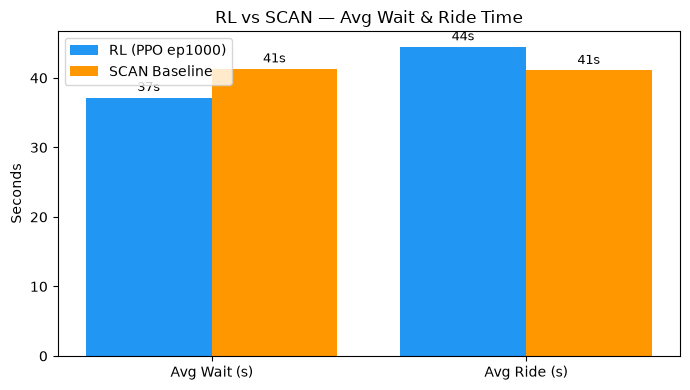

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

def get_metrics(env):
    df = pd.DataFrame(env.logs)
    if df.empty:
        return None
    return {
        'wait': df[df['mode'] == 'elevator_waiting']['wait_time'].mean(),
        'ride': df[df['mode'] == 'elevator_drive']['travel_time'].mean(),
        'done': len(env.left_guests),
    }

rl_m   = get_metrics(rl_env)
scan_m = get_metrics(scan_env)
n_cars = rl_env.num_elevators

if rl_m and scan_m:
    labels = ['Avg Wait (s)', 'Avg Ride (s)']
    rl_vals   = [rl_m['wait'],   rl_m['ride']]
    scan_vals = [scan_m['wait'], scan_m['ride']]

    x = range(len(labels))
    fig, ax = plt.subplots(figsize=(7, 4))
    bars1 = ax.bar([i - 0.2 for i in x], rl_vals,   0.4, label=f'RL (PPO {n_cars}-car)', color='#2196F3')
    bars2 = ax.bar([i + 0.2 for i in x], scan_vals, 0.4, label=f'Group SCAN ({n_cars}-car)', color='#FF9800')
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels)
    ax.set_ylabel('Seconds')
    ax.set_title(f'RL vs SCAN — {n_cars}-car bank, Avg Wait & Ride Time')
    ax.legend()
    for bar in bars1 + bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.0f}s', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()
